# 🌤 Hava Durumu Sıcaklığı

🔥 Bu, Python ve RNN bilginizi gerçekten test edecek uzun bir meydan okuma.

🧑🏻‍🎓 Her şeyi dikkatli okuyun.

💻 Kodlama bölümleri `laptop` emojisiyle belirtilmiştir.

⏳ Bugün bitirmezseniz, bootcamp sonrasında geri dönmeye değer bir meydan okuma.

### Kütüphaneler

1. Gerekli kütüphaneleri içe aktaralım:

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

# Data Visualiation
import matplotlib.pyplot as plt
import seaborn as sns

# System
import os

# Deep Learning
import tensorflow as tf


2026-03-27 16:01:10.023966: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2. Zamansal verileri manipüle etmek zordur, Python fonksiyonlarımızda kullanacağımız değişkenlerin tiplerini kontrol etmek için 📚 [`typing`](https://docs.python.org/3/library/typing.html) kütüphanesini de içe aktaralım:

In [2]:
from typing import Dict, List, Tuple, Sequence


# (0) Hava durumu sıcaklık meydan okuma

## (0.0) Giriş

🧑🏻‍🏫 **Hedefler:**
- Bir Tekrarlayan Sinir Ağına beslenecek veri setini hazırlamak
- Zaman Serileri hakkında daha iyi anlayış geliştirmek

❗️ **Uyarı/Feragatname**:
- Bu meydan okuma gerçekten **zamansal verilerle nasıl başa çıkılacağını** anlamanıza yardımcı olmak için tasarlanmıştır, LSTM mimarisini bir _araç_ olarak kullanarak, LSTM'nin farklı kapılarına odaklanmak veya "en iyi" tekrarlayan ağı tasarlamak için değil.

🎯 **ML hedefi**:
* Bu meydan okumada, **önümüzdeki 3, 6, 9, 12... saatlerdeki sıcaklığı tahmin etmek** istiyoruz...
* ..._geçmiş sıcaklık_, _atmosferik basınç_, _nem_ vb. gibi hava durumu özelliklerinin bir dizisine dayanarak.

## (0.1) Hava durumu veri seti

### (0.1.1) Veri setini yükleme

🌤 Bu meydan okuma [**Max-Planck-Institute for Biogeochemistry**](https://www.bgc-jena.mpg.de/index.php/Main/HomePage) tarafından kaydedilen bir [**hava durumu zaman serisi veri seti**](https://www.bgc-jena.mpg.de/wetter/) kullanır. Bu veri seti 2003'ten itibaren her 10 dakikada bir toplanan _hava sıcaklığı_, _atmosferik basınç_ ve _nem_ gibi $14$ farklı özellik içerir (~ 420k satır). Ancak verimlilik için, 2009 ile 2016 arasında her üç saatte bir toplanan verileri "sadece" kullanacaksınız. Gerçekten de, bu zaman aralığı belirli bir gün boyunca sıcaklığın evrimini gözlemlemek için makul görünmektedir.

🛠 Sizin için önceden aşağıdaki özellik mühendisliği adımlarını gerçekleştirdik:
- her üç saatte bir tahminlere odaklanmak için her $18$. kayıtı almak $ ( 18 =  \frac{6 kayıt}{saat} \times 3 saat)$
- saçma değerleri değiştirmek
- _rüzgar_: rüzgar yönlerini (`Wx`, `Wy`) koordinatları ile rüzgar vektörleri olarak hesaplamak
- (`Day sin`, `Day cos`) ve (`Year sin`, `Year cos`) ile saklanan _günlük ve yıllık periyodiklikleri_ hesaplamak

👇 Bize güvenin ve bu meydan okuma için bu önceden işlenmiş veri setinden başlayın 👇

In [5]:
import pandas as pd
import requests
import io

# URL'miz
url = "https://d37p7d5kaxknzw.cloudfront.net/projects/weather_every_three_hours.csv"

# requests kütüphanesi ile veriyi indiriyoruz (SSL doğrulamasını kapatarak: verify=False)
response = requests.get(url, verify=False)

# İndirilen veriyi pandas'ın okuyabileceği bir formata çevirip DataFrame'e dönüştürüyoruz
df = pd.read_csv(io.StringIO(response.text)).drop(columns=['Unnamed: 0'])

# Tablonun ilk 5 satırını görelim
df.head()


/Users/macos/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'd37p7d5kaxknzw.cloudfront.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day_sin,Day_cos,Year_sin,Year_cos
0,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,7.071068e-01,7.071068e-01,0.011483,0.999934
1,997.71,-9.67,263.66,-10.62,92.7,2.93,2.71,0.21,1.69,2.72,1317.71,-0.041452,0.027960,-0.414519,0.279596,1.000000e+00,4.339955e-12,0.013633,0.999907
2,999.69,-7.66,265.52,-8.84,91.2,3.43,3.13,0.30,1.95,3.13,1310.14,-0.314796,-0.128466,-0.583298,-0.238040,7.071068e-01,-7.071068e-01,0.015783,0.999875
3,1000.30,-6.87,266.27,-8.28,89.6,3.64,3.27,0.38,2.03,3.26,1306.98,-1.834577,-0.141163,-2.622249,-0.201771,6.903299e-12,-1.000000e+00,0.017933,0.999839
4,999.88,-5.69,267.48,-7.00,90.4,3.99,3.61,0.38,2.25,3.61,1300.51,-0.825870,0.828758,-1.327039,1.331679,-7.071068e-01,-7.071068e-01,0.020083,0.999798


👆 Önceden işlenmiş veri setinde şunlar var:
- $23$k satır (~ 8 yıllık hava durumu verisi)
- Aşağıdakilerden oluşan $19$ özellik:
    - $1$ <font color=green>**hedef**</font> (sıcaklığın geçmiş değerlerini bir özellik olarak kullanacağız)
    - $18$ <font color=orange>**geçmiş kovaryal**</font> (= geçmiş değerleri bilinen özellikler)
    - $0$ <font color=blue>**gelecek kovaryal**</font> (= gelecek değerleri bilinen özellikler, örn. resmi tatiller)

    
<img src='https://github.com/lewagon/data-images/blob/master/DL/time-series-covariates.png?raw=true' width=800>

👨🏻‍🏫 Bu hava durumu veri seti, 2009 başından 2016 sonuna kadar her 3 saatte bir kayıtla tekil bir Zaman Serisi olan bir DataFrame'dir (boyut = 2).

* `df.shape = (n_timesteps, n_features) = (23363, 19)`

<details>
    <summary>Toplamda 8 yıllık veriye sahibiz</summary>

$ \frac{23363 kayıt}{365 \frac{gün}{yıl} \times 24 \frac{saat}{gün} \times \frac{1 kayıt}{3 saat}} = \frac{23363 kayıt}{2920 \frac{kayıt}{yıl}} = 8 yıl = (2016 - 2009 + 1 ) yıl$
    
</details>

🎯 Hedef, geçmiş değerleri kullanarak 3, 6, 9, 12, ... saat sonraki sıcaklığı tahmin etmektir.

In [6]:
# Let's define the global variables of our dataset
TARGET = 'T (degC)'
N_TARGETS = 1
N_FEATURES = 19


### (0.0.2) Zaman Serinizi Görselleştirme

📈 ***Bazı özelliklerin zaman içinde evrimi***:
* `T (degC)` (sıcaklık)
* `p (mbar)` (atmosferik basınç)
* `rho (g/m**3)` (atmosferik yoğunluk)



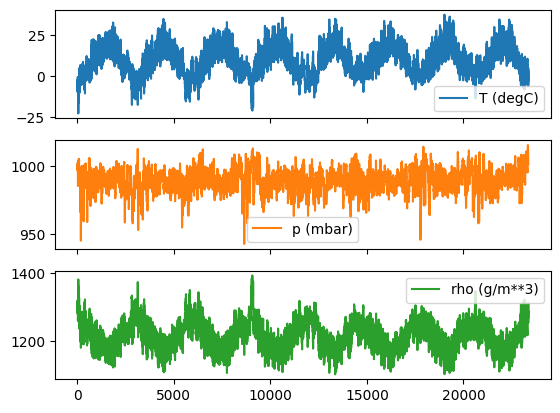

In [7]:
plot_cols = [TARGET, 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = df.index
plot_features.plot(subplots = True);


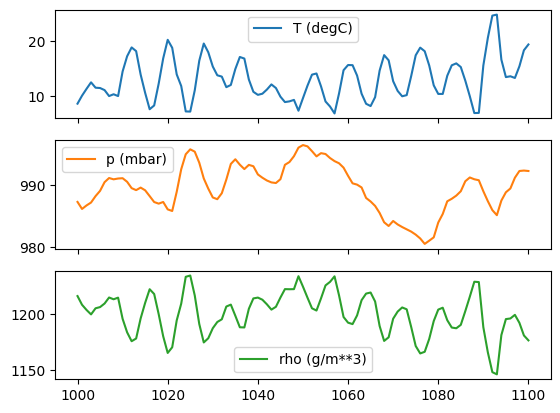

In [8]:
zoomed_slice = slice(1000,1100)

plot_features = df.loc[zoomed_slice, plot_cols]
plot_features.plot(subplots = True);


# (1) Veri setini hazırlama

##  (1.0) Büyük resim

<b><u>Adım 1: Zaman Serisinde Çapraz Doğrulama [KATMANLAR] </u></b>

* Bu tekil Zaman Serisinden başlayarak, <font color="#c91ac9">**KATMANLAR**</font> oluşturacağız...
* ... ve sinir ağının sağlamlığı hakkında sonuç çıkarmak için LSTM'i bu farklı <font color="#c91ac9">**KATMANLARDA**</font> eğiteceğiz/değerlendireceğiz
* Zaman Serisi tahminlemede ***yüzlerce*** <font color="#c91ac9">**KATMAN**</font> oluşturmak çok yaygındır, tüm dış koşul tiplerini kapsamak için: örn.
    - çöküş piyasa dönemleri 📉
    - boqa piyasaları 📈
    - düz piyasalar 😴, vb...

<b><u>Adım 2: Her katman içinde Holdout yöntemi [EĞİTİM-TEST AYIRIMI]</u></b>

* Her <font color="#c91ac9">**KATMAN**</font> için, EĞİTİM-TEST AYIRIMI yapacağız:
    * modeli <font color=blue>**eğitim**</font> setinde <font color=blue>**eğitmek**</font> 
    * ve <font color="#ff8005">**test**</font> setinde <font color="#ff8005">**değerlendirmek**</font>
    * Eğitim setini her zaman test setinden **kronolojik olarak** önce ayırın!

👇 İlk iki adım, 4 KATMAN içeren aşağıdaki görüntüde özetlenebilir:

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time_series_cross_validation.png" alt="Time Series Cross Validation" width="800">

<b><u>Adım 3: Hem eğitim setinde hem de test setinde DİZİLER örnekleme</u></b>

Her <font color=blue>**eğitim**</font> setinde ve her <font color="#ff8005">**test**</font> setinde, aşağıda gösterildiği gibi <font color=magenta>**rastgele diziler**</font> oluşturacağız 👇:

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/big_picture_temporal_data_handling.png" alt="Sequences in each fold" width="500"> 



## (1.1) 💻 Çapraz doğrulama için <font color="#c91ac9">**KATMANLAR**</font> oluşturma

Her biri `(FOLD_LENGTH, n_features)` şeklinde 

🌐 Bu notebook'ta her yerde testlerimiz için kullanacağımız bazı global değişkenleri tanımlayalım:

In [9]:
# --------------------------------------------------- #
# Let's consider FOLDS with a length of 3 years       #
# (2 years will be used for train, 1 for test!)       #
# --------------------------------------------------- #

FOLD_LENGTH = 8*365 * 3 # every 3 hrs x 8 = 24h
                        # three years

# --------------------------------------------------- #
# Let's consider FOLDS starting every trimester       #
# --------------------------------------------------- #

FOLD_STRIDE = 8*91 # every 3 hrs x 8 = 24h
                   # 1 quarter = 91 days

# --------------------------------------------------- #
# Let's consider a train-test-split ratio of 2/3      #
# --------------------------------------------------- #

TRAIN_TEST_RATIO = 0.66


💻 ❓ **Soru (<font color="#c91ac9">KATMANLAR</font>)** ❓

Katmanları oluşturmak için kullanacağımız `get_folds` fonksiyonunu aşağıda kodlayın `folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)`

In [10]:
def get_folds(
    df: pd.DataFrame,
    fold_length: int,
    fold_stride: int) -> List[pd.DataFrame]:
    """
    Bu fonksiyon, (n_timesteps, n_features) şeklindeki Zaman Serisi dataframe'ini tararak katmanlar oluşturur
    - eşit `fold_length` uzunluğunda
    - her katman arasında `fold_stride` kullanarak

    Args:
        df (pd.DataFrame): Genel dataframe
        fold_length (int): Her katmanın satır cinsinden ne kadar uzun olacağı
        fold_stride (int): Her katman alırken kaç zaman adımı ileri gidileceği

    Returns:
        List[pd.DataFrame]: Her katmanın bir dataframe olduğu bir liste
    """
    folds = []
    
    # 0'dan başlayıp, son katmanın sığabileceği yere kadar fold_stride adımlarla ilerliyoruz
    for i in range(0, len(df) - fold_length + 1, fold_stride):
        # Dataframe'den başlangıç noktası (i) ile bitiş noktası (i + fold_length) arasını kesip alıyoruz
        fold = df.iloc[i:i + fold_length]
        folds.append(fold)
        
    return folds


🧪 ***Test your code***

In [11]:
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

print(f'Fonksiyon {len(folds)} katman oluşturdu.')
print(f'Her katmanın şekli {folds[0].shape} eşittir.')


Fonksiyon 21 katman oluşturdu.
Her katmanın şekli (8760, 19) eşittir.


In [12]:
from nbresult import ChallengeResult

result = ChallengeResult('folds',
                         number_of_folds = len(folds),
                         fold_shape = folds[0].shape)
result.write()
print(result.check())



============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S18D5-S-data-temperature-prediction/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_folds.py::TestFolds::test_variable_fold_shape PASSED                [ 50%]
test_folds.py::TestFolds::test_variable_number_of_folds PASSED           [100%]

============================== 2 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/folds.pickle

git commit -m 'Completed folds step'

git push origin master



☝️ Bu miktar <font color="#c91ac9">**KATMAN**</font> modelimizi doğru bir şekilde çapraz doğrulamak için yeterli olmalı !

## (1.2) 💻 Zamansal <font color=blue>**Eğitim**</font>/<font color="#ff8005">**Test**</font> Ayrımı

👩🏻‍🏫 Şimdilik bir katmana odaklanalım.

In [13]:
fold = folds[0]
fold


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day_sin,Day_cos,Year_sin,Year_cos
0,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,7.071068e-01,7.071068e-01,0.011483,0.999934
1,997.71,-9.67,263.66,-10.62,92.7,2.93,2.71,0.21,1.69,2.72,1317.71,-0.041452,0.027960,-0.414519,0.279596,1.000000e+00,4.339955e-12,0.013633,0.999907
2,999.69,-7.66,265.52,-8.84,91.2,3.43,3.13,0.30,1.95,3.13,1310.14,-0.314796,-0.128466,-0.583298,-0.238040,7.071068e-01,-7.071068e-01,0.015783,0.999875
3,1000.30,-6.87,266.27,-8.28,89.6,3.64,3.27,0.38,2.03,3.26,1306.98,-1.834577,-0.141163,-2.622249,-0.201771,6.903299e-12,-1.000000e+00,0.017933,0.999839
4,999.88,-5.69,267.48,-7.00,90.4,3.99,3.61,0.38,2.25,3.61,1300.51,-0.825870,0.828758,-1.327039,1.331679,-7.071068e-01,-7.071068e-01,0.020083,0.999798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,980.34,1.45,276.18,0.03,90.2,6.79,6.12,0.67,3.89,6.24,1240.67,-0.604351,-3.731375,-1.191115,-7.354165,-8.715574e-02,-9.961947e-01,-0.028744,0.999587
8756,983.25,2.23,276.73,0.21,86.4,7.18,6.20,0.98,3.93,6.31,1240.81,-0.432628,-2.126437,-0.849307,-4.174479,-7.660444e-01,-6.427876e-01,-0.026594,0.999646
8757,985.46,1.69,276.00,-0.52,85.2,6.90,5.88,1.02,3.72,5.97,1246.23,-0.626578,-2.513066,-0.977364,-3.919995,-9.961947e-01,8.715574e-02,-0.024445,0.999701
8758,986.63,2.16,276.38,-1.14,78.7,7.14,5.62,1.52,3.55,5.70,1245.68,-0.773266,-3.669409,-1.222791,-5.802558,-6.427876e-01,7.660444e-01,-0.022295,0.999751


☝️ Bu katmanı **kronolojik olarak** şunlara ayırmak istiyoruz:

- bir <font color=blue>fold_train</font> dataframe'i
- bir <font color="#ff8005">fold_test</font> dataframe'i

bir sonraki adımda her dataframe'de çok sayıda `(X_i, y_i)` çifti örnekleyebilmek için ihtiyaç duyacağımız tüm veriyi içerecek!

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time_serie_test_split_without_horizon.png" alt="train_test_split_temporal" width="800"> 


☝️ Fark ettin mi?

- <font color="#ff8005">y_test_first</font> <font color=blue>y_train_last</font>'tan hemen sonra olmalı
  
- <font color="#ff8005">fold_test</font>'imizde hangi indekslerin olması gerektiğini bilmek için, her `X_i` gözleminin `INPUT_LENGTH` uzunluğunu bilmemiz gerekiyor
  
- `INPUT_LENGTH` büyük olabileceği için, eğitim ve test katmanları arasında bir örtüşme olması tamamen normaldir! (1 yıllık input_length alındığını düşünün, eğitim ve test arasında bir yıl beklemezdiniz!)


**❓ Anlama Sorusu**: <font color=blue>fold_train</font> zaman adımı indekslerinin `[O..len_train]` aralığında olduğu göz önüne alındığında, <font color="#ff8005">fold_test</font> indeks aralığı ne olmalıdır?

<details>
  <summary markdown='span'>💡 Cevap</summary>

Eğer `fold_train` indeksleri `[0:len_train]` ise, o zaman `fold_test` indeksleri `[len_train-INPUT_LENGTH, :]` olacaktır
</details>



✅ O halde problemimiz için `INPUT_LENGTH`'i 2 haftaya eşit olarak ayarlayalım (hava durumu tahmini için oldukça yaygın bir süre)

In [14]:
INPUT_LENGTH = 8 * 14 # records every 3 hours x 8 = 24 hours
                      # two weeks


💻 ❓ **Soru (zamansal <font color=blue>eğitim</font>-<font color=orange>test</font> ayrımı)** ❓

Aşağıdaki `train_test_split` fonksiyonunu kodlayın:
- <i>(girdi)</i> bir `fold` (yukarıdaki gibi), bir `train_test_ratio` (örn. 0.8) ve bir `input_length` (sabit) verildiğinde
- <i>(çıktı)</i> (`fold_train`, `fold_test`) dataframe'lerinin bir tuple'ı

In [15]:
def train_test_split(fold:pd.DataFrame,
                     train_test_ratio: float,
                     input_length: int) -> Tuple[pd.DataFrame]:
    """From a fold dataframe, take a train dataframe and test dataframe based on
    the split ratio.
    - df_train should contain all the timesteps until round(train_test_ratio * len(fold))
    - df_test should contain all the timesteps needed to create all (X_test, y_test) tuples

    Args:
        fold (pd.DataFrame): A fold of timesteps
        train_test_ratio (float): The ratio between train and test 0-1
        input_length (int): How long each X_i will be

    Returns:
        Tuple[pd.DataFrame]: A tuple of two dataframes (fold_train, fold_test)
    """
   # 1. Eğitim setinin nerede biteceğini (kaçıncı satır) hesaplayalım
    # fold'un toplam uzunluğunu oran ile çarpıp yuvarlıyoruz
    train_end_index = round(len(fold) * train_test_ratio)
    
    # 2. Eğitim setini alalım (Baştan train_end_index'e kadar)
    fold_train = fold.iloc[0 : train_end_index]
    
    # 3. Test setini alalım
    # DİKKAT: Test seti eğitim setinin bittiği yerden başlamaz! 
    # Testteki ilk tahmini yapabilmek için "input_length" kadar geriye gitmeliyiz.
    fold_test = fold.iloc[train_end_index - input_length : ]
    
    return fold_train, fold_test


🧪 ***Test your code***

In [16]:
TRAIN_TEST_RATIO


0.66

In [17]:
(fold_train, fold_test) = train_test_split(fold, TRAIN_TEST_RATIO, INPUT_LENGTH)


In [18]:
from nbresult import ChallengeResult

result = ChallengeResult('holdout',
                         train_index_start = fold_train.index.start,
                         train_index_stop = fold_train.index.stop,
                         test_index_start = fold_test.index.start,
                         test_index_stop = fold_test.index.stop)
result.write()
print(result.check())



============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S18D5-S-data-temperature-prediction/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_holdout.py::TestHoldout::test_variable_test_index_start PASSED      [ 25%]
test_holdout.py::TestHoldout::test_variable_test_index_stop PASSED       [ 50%]
test_holdout.py::TestHoldout::test_variable_train_index_start PASSED     [ 75%]
test_holdout.py::TestHoldout::test_variable_train_index_stop PASSED      [100%]

============================== 4 passed in 0.05s ===============================


💯 You can commit your code:

git add tests/holdout.pickle

git commit -m 'Completed holdout step'

git push origin master



## (1.3) 💻 (X, y) dizileri oluşturma

Katmanımızı bir <font color="blue">eğitim</font> seti ve bir <font color="#ff8005">test</font> setine ayırdığımıza göre, şimdi zamanı geldi:
- 🏋 modelin <font color="blue">eğitileceği</font> çok sayıda $(X_i, y_i)$ dizisi örnekleme
- 👩🏻‍🏫 modelin <font color="#ff8005">değerlendirileceği</font> çok sayıda $(X_i, y_i)$ dizisi örnekleme

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/big_picture_temporal_data_handling.png" alt="Sequences in each fold" width="300"> 

🎯 Hedefimiz bu katmandan ihtiyacımız olan tüm DİZİLERİ içeren 3D-arrayler `(X_train, y_train)` ve `(X_test, y_test)` oluşturmaktır:

* `X_train.shape = (n_samples_train, input_length, n_features)`
* `y_train.shape = (n_samples_train, output_length, n_targets)`

👉 Artık **2D DataFrames** zaman serileri yerine **3D arrayler** ile uğraştığımızı unutmayın

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/three_dimensional_time_series.png" alt="3d arrays time series" width="1200"> 

In [19]:
# INPUT X
print(f'N_FEATURES = {N_FEATURES}')
print(f'INPUT_LENGTH = {INPUT_LENGTH} timesteps = {int(INPUT_LENGTH/8)} days = {int(INPUT_LENGTH/8/7)} weeks')


N_FEATURES = 19
INPUT_LENGTH = 112 timesteps = 14 days = 2 weeks


☝️ `X` modelimizin **girdisi**dir.
- $19$ özellik içerir: <font color=green>**hedefin**</font> geçmiş değerleri + $18$ <font color=orange>**geçmiş-kovaryat**</font>
- Her dizinin uzunluğu $112$ zaman adımına ($=2$ hafta) eşittir

In [20]:
# TARGET Y
print(f'N_TARGETS = {N_TARGETS}')

# Let's only predict 1 value ahead of us
OUTPUT_LENGTH = 1
print(f'OUTPUT_LENGTH = {OUTPUT_LENGTH}')


N_TARGETS = 1
OUTPUT_LENGTH = 1


☝️ `y` tahmin etmek istediğimiz <font color=green>**hedef**</font>tir:
- Tek bir sonraki zaman adımındaki değerdir (= 3 saat sonra)
- Ayrıca `OUTPUT_LENGTH > 1` tahmin edebiliriz, yani gelecekteki birkaç değer _(3 saat sonra, 6 saat sonra, 9 saat sonra, ...)_ ama burada basit tutalım ve sadece bir sonraki nokta tahmin etmeye çalışalım (3 saat içinde)

💡 <font color="blue">eğitim</font> seti ve <font color="#ff8005">test</font> seti içinde bu DİZİLERİ oluşturmak için birkaç seçeneğiniz var:
- 🎲 <u><i>Seçenek 1</i></u>: <font color="blue">fold_train</font> ve <font color="#ff8005">fold_test</font>'ten rastgele $(X_i, y_i)$ örnekleyerek bu dizileri oluşturmak.
- ⌚️ <u><i>Seçenek 2</i></u>: bir katmanı kronolojik olarak tarayarak mümkün olan tüm $(X_i, y_i)$ çiftlerini oluşturmak.
 

👉 İlk seçeneğe odaklanalım: rastgele örnekleme

🎁 Katmanları kronolojik olarak taramak istiyorsanız, bölümde çözümü sağladık ve daha sonra geri dönebilirsiniz


### (1.2.1) 💻 Seçenek 1: Her ayrımda rastgele örnekleme ile (X, y) oluşturma

👇 Kodlayacağımız:

* 1️⃣ bir katman içinden rastgele tek bir dizi üretmek için `get_Xi_yi` fonksiyonu

* 2️⃣ bir katmandan birden fazla dizi içeren 3D-arrayler üretmek için `get_X_y` fonksiyonu, ilk `get_Xi_yi` fonksiyonunu birçok kez çağırarak

#### (1.2.2.1) 💻 Tek rastgele dizi üretme

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/get_xi_yi.png" alt="one sequence" width="400"> 

💻 ❓ **Soru (katmandan rastgele dizi çıkarma)** ❓

Aşağıdaki `get_Xi_yi` fonksiyonunu kodlayın:
- <i>(girdi)</i> bir katman, bir `input_length` ve bir `output_length` verildiğinde
- <i>(çıktı)</i> bir $(X_i,y_i)$ dizisi döndürür

In [23]:
import random
from typing import Tuple
import pandas as pd

def get_Xi_yi(
    fold: pd.DataFrame, 
    input_length: int, 
    output_length: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    '''
    Bir fold içinden rastgele bir başlangıç noktası seçerek, 
    input_length uzunluğunda X ve output_length uzunluğunda y dizilerini döndürür.
    '''
    
    # Başlangıç noktasını rastgele seçebileceğimiz en son indeksi buluyoruz
    max_start_idx = len(fold) - input_length - output_length
    
    # 0 ile max_start_idx arasında rastgele bir indeks seçiyoruz
    start_idx = random.randint(0, max_start_idx)
    
    # X dizisini kesiyoruz (start_idx'ten başlayıp input_length kadar ileri)
    X_i = fold.iloc[start_idx : start_idx + input_length]
    
    # y dizisini kesiyoruz (X'in bittiği yerden başlayıp output_length kadar ileri)
    # y sadece TARGET (sıcaklık) sütununu içermelidir
    y_i = fold.iloc[start_idx + input_length : start_idx + input_length + output_length][[TARGET]]
    
    return X_i, y_i

🧪 ***Kodunuzu aşağıda test edin***

In [24]:
X_train_i, y_train_i = get_Xi_yi(fold_train, INPUT_LENGTH, OUTPUT_LENGTH)
X_test_i, y_test_i = get_Xi_yi(fold_test, INPUT_LENGTH, OUTPUT_LENGTH)


In [25]:
from nbresult import ChallengeResult

result = ChallengeResult('sequence',
                         x_train_i_shape = X_train_i.shape,
                         y_train_i_shape = y_train_i.shape,
                         x_test_i_shape = X_test_i.shape,
                         y_test_i_shape = y_test_i.shape)
result.write()
print(result.check())



============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S18D5-S-data-temperature-prediction/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_sequence.py::TestSequence::test_variable_x_test_i_shape PASSED      [ 25%]
test_sequence.py::TestSequence::test_variable_x_train_i_shape PASSED     [ 50%]
test_sequence.py::TestSequence::test_variable_y_test_i_shape PASSED      [ 75%]
test_sequence.py::TestSequence::test_variable_y_train_i_shape PASSED     [100%]

============================== 4 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/sequence.pickle

git commit -m 'Completed sequence step'

git push origin master



In [26]:
# Advanced check 😈
# You should not allow some truncated (X_i,y_i) pairs to be generating,
# should you start sampling too close from the end of the fold... !

X_last, y_last = get_Xi_yi(fold_test, input_length=len(fold_test)-1, output_length=OUTPUT_LENGTH)
assert y_last.values == fold_test.iloc[-1,:][TARGET]


#### (1.2.2.2) 💻 Birden fazla rastgele dizi üretme

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/rnn-1.png" alt="Sequences in each fold" width="500"> 

💻 ❓ **Soru (katmandan birden fazla rastgele dizi çıkarma)** ❓

Aşağıdaki `get_X_y` fonksiyonunu kodlayın:
- <i>(girdi)</i> bir katman, bir `number_of_sequences`, bir `input_length` ve bir `output_length` verildiğinde
- <i>(çıktı)</i> $(X,y)$ döndürür

_Az önce kodladığınız `get_Xi_yi` fonksiyonunu kullanmayı unutmayın!_

In [27]:
import numpy as np

def get_X_y(
    fold: pd.DataFrame,
    number_of_sequences: int,
    input_length: int,
    output_length: int) -> Tuple[np.array, np.array]:
    '''
    Belirtilen sayıda (number_of_sequences) X ve y dizisi üretir.
    '''
    
    # Lokmaları toplayacağımız boş listeler
    X_list = []
    y_list = []
    
    # İstenilen sayı kadar döngüye giriyoruz
    for _ in range(number_of_sequences):
        # Az önce yazdığımız sihirli fonksiyonu çağırıyoruz
        X_i, y_i = get_Xi_yi(fold, input_length, output_length)
        
        # Gelen dataframe'leri numpy array'ine (.values) çevirip listemize ekliyoruz
        X_list.append(X_i.values)
        y_list.append(y_i.values)
        
    # Listeleri 3D Numpy Array'e çevirip döndürüyoruz
    return np.array(X_list), np.array(y_list)

🧪 ***Test your code***

In [28]:
N_TRAIN = 6666 # number_of_sequences_train
N_TEST =  3333 # number_of_sequences_test

X_train, y_train = get_X_y(fold_train, N_TRAIN, INPUT_LENGTH, OUTPUT_LENGTH)
X_test, y_test = get_X_y(fold_test, N_TEST, INPUT_LENGTH, OUTPUT_LENGTH)


In [29]:
from nbresult import ChallengeResult

result = ChallengeResult('multiple_sequences',
                         x_train_shape = X_train.shape,
                         y_train_shape = y_train.shape,
                         x_test_shape = X_test.shape,
                         y_test_shape = y_test.shape)
result.write()
print(result.check())



============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S18D5-S-data-temperature-prediction/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_multiple_sequences.py::TestMultipleSequences::test_variable_x_test_i_shape PASSED [ 25%]
test_multiple_sequences.py::TestMultipleSequences::test_variable_x_train_shape PASSED [ 50%]
test_multiple_sequences.py::TestMultipleSequences::test_variable_y_test_i_shape PASSED [ 75%]
test_multiple_sequences.py::TestMultipleSequences::test_variable_y_train_shape PASSED [100%]

============================== 4 passed in 0.04s ===============================


💯 You can commit your code:

git add tests/multiple_sequences.pickle

git commit -m 'Completed multiple_sequences step'

git push origin master



### (1.2.2) (Şimdi bunu okumayın, daha sonra saklayın) 🎁 Seçenek 2: Kronolojik tarama

Daha önce belirtildiği gibi, bir katmandan dizi çıkartmanın birden fazla yolu vardır.

- 🎲 Önceki bölümde kodladınız:
    - `get_Xi_yi` rastgele _bir_ dizi örnekler
    - ve `get_X_y` rastgele _birden fazla_ dizi üretir

- ⌚️ Bu bölümde, size benzersiz bir `get_X_y_strides` fonksiyonu sağlıyoruz.
    - Bir katmanı kronolojik olarak tarar:
         - bir `input_length` (hala `INPUT_LENGTH = 8 * 14`, yani iki hafta kullanalım)
         - ve bir `sequence_stride` (tek boyutlu konvolisyonel işlem düşünün!)

👉 Katmanı 3 saatlik zamansal stride ile (minimum olan) tarayalım:

In [30]:
SEQUENCE_STRIDE = 1


In [31]:
def get_X_y_strides(fold: pd.DataFrame, input_length: int, output_length: int,
    sequence_stride: int) -> Tuple[np.array]:
    """slides through a `fold` Time Series (2D array) to create sequences of equal
        * `input_length` for X,
        * `output_length` for y,
    using a temporal gap `sequence_stride` between each sequence

    Args:
        fold (pd.DataFrame): One single fold dataframe
        input_length (int): Length of each X_i
        output_length (int): Length of each y_i
        sequence_stride (int): How many timesteps to take before taking the next X_i

    Returns:
        Tuple[np.array]: A tuple of numpy arrays (X, y)
    """
    X, y = [], []

    for i in range(0, len(fold), sequence_stride):
        # Exits the loop as soon as the last fold index would exceed the last index
        if (i + input_length + output_length) >= len(fold):
            break
        X_i = fold.iloc[i:i + input_length, :]
        y_i = fold.iloc[i + input_length:i + input_length + output_length, :][[TARGET]]
        X.append(X_i)
        y.append(y_i)

    return (np.array(X), np.array(y))


🧑🏻‍🎓 Bir katmanı sırasıyla tarama hakkında bazı açıklamalar:

In [32]:
print("FOLD_LENGTH")
print(f"= {FOLD_LENGTH} timesteps")
print(f"= {int(FOLD_LENGTH/8)} days") # 8 records per day, every 3 hours
print(f"= {int(FOLD_LENGTH/8/7)} weeks")


FOLD_LENGTH
= 8760 timesteps
= 1095 days
= 156 weeks


In [33]:
X_train, y_train = get_X_y_strides(fold_train, INPUT_LENGTH, OUTPUT_LENGTH, SEQUENCE_STRIDE)
X_test, y_test = get_X_y_strides(fold_test, INPUT_LENGTH, OUTPUT_LENGTH, SEQUENCE_STRIDE)

print(X_train.shape)
print(y_train.shape)


(5669, 112, 19)
(5669, 1, 1)


👇 Illustration down below if *SEQUENCE_STRIDE = 1 week*

<img src="https://github.com/lewagon/data-images/blob/master/DL/scanning_a_time_series_chronologically_v3.png?raw=true" width=800>

# (2) 💻 Modelleme

**Sıcaklık tahminini izlemek için metrik olarak MAE**

Ortalama Mutlak Hata, bir modelin sıcaklık tahmin etme kapasitesini değerlendirmek için makul bir metrik gibi görünmektedir:

$$ MAE = \frac{1}{n_{samples}} \times \sum_{i = 1}^{n_{samples}} |y_{true}^{(i)} - y_{pred}^{(i)}|$$

## (2.1) 💻 Tekrarlayan Sinir Ağı: `LSTM`

🚀 Bir Tekrarlayan Sinir Ağı tasarlamanın ve umarız temel modeli yenmenin zamanı geldi 💪 !

💻 ❓ **Soru (RNN)** ❓

- Bir LSTM katmanıyla basit bir Tekrarlayan Sinir Ağı oluşturan ve derleyen bir `init_model` fonksiyonu oluşturun
- Verinizi bir [📚 Normalizasyon katmanı](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization) ile normalize etmeyi unutmayın

In [35]:
from keras import models, layers, Input, optimizers, metrics
from keras.regularizers import L1L2
from keras.layers import Normalization

def init_model(X_train, y_train):
    """
    Basit bir LSTM modeli oluşturur, derler ve döndürür.
    """
    # 1. Normalizasyon katmanını oluştur ve eğitim verisine uyarla
    normalizer = Normalization()
    normalizer.adapt(X_train)
    
    # 2. Modeli inşa et (Sequential API)
    model = models.Sequential()
    
    # Girdi katmanı: 112 zaman adımı, 19 özellik
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
    
    # Normalizasyon katmanını ekle
    model.add(normalizer)
    
    # Bir LSTM katmanı ekle (Örn: 20 hafıza birimi)
    model.add(layers.LSTM(units=20, activation='tanh'))
    
    # Çıktı katmanı: Tek bir değer tahmin edeceğimiz için 1 nöron
    model.add(layers.Dense(units=1, activation='linear'))
    
    # 3. Modeli derle (Compile)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model


In [36]:
model = init_model(X_train, y_train)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 112, 19)        │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20)             │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,260 (12.74 KB)

 Trainable params: 3,221 (12.58 KB)

 Non-trainable params: 39 (160.00 B)

🛠 🎁 📉 RNN'nizin epochlar üzerindeki eğitimini görselleştirmeniz için sizin için bir `plot_history` fonksiyonu kodladık. Bu fonksiyon hem kayıp fonksiyonunun (MSE) hem de metriklerin (MAE) evrimini gösterir.

In [37]:
def plot_history(history):

    fig, ax = plt.subplots(1,2, figsize=(20,7))
    # --- LOSS: MSE ---
    ax[0].plot(history.history['loss'])
    ax[0].plot(history.history['val_loss'])
    ax[0].set_title('MSE')
    ax[0].set_ylabel('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend(['Train', 'Validation'], loc='best')
    ax[0].grid(axis="x",linewidth=0.5)
    ax[0].grid(axis="y",linewidth=0.5)

    # --- METRICS:MAE ---

    ax[1].plot(history.history['mae'])
    ax[1].plot(history.history['val_mae'])
    ax[1].set_title('MAE')
    ax[1].set_ylabel('MAE')
    ax[1].set_xlabel('Epoch')
    ax[1].legend(['Train', 'Validation'], loc='best')
    ax[1].grid(axis="x",linewidth=0.5)
    ax[1].grid(axis="y",linewidth=0.5)

    return ax


💻 ❓ **Sorular (eğitim ve değerlendirme)** ❓

- Aşağıdaki özelliklere sahip `fit_model()` metodunu kodlayın:
    - <i>(girdi)</i> bir `model` verildiğinde
    - <i>(çıktı)</i> bir tuple aracılığıyla eğitilmiş modeli döndürür `(model, history)`
- Sonra:
    - `init_model` fonksiyonuyla bir RNN modeli başlatın
    - Modeli <font color=blue>Eğitin</font>
    - Test setinde <font color=orange>Değerlendirin</font>

Model eğitimi başlıyor...
Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 108.8693 - mae: 8.2840 - val_loss: 42.5133 - val_mae: 5.1577
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 50.4829 - mae: 5.2891 - val_loss: 25.7755 - val_mae: 3.8905
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 33.4258 - mae: 4.1413 - val_loss: 17.3345 - val_mae: 3.0508
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 23.5389 - mae: 3.3695 - val_loss: 12.2267 - val_mae: 2.4706
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 17.2358 - mae: 2.8420 - val_loss: 9.1444 - val_mae: 2.1385
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 13.1825 - mae: 2.4747 - val_loss: 7.4856 - val_mae: 1.9671
Epoch 7/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 10.4839 - mae: 2.2040 - val_loss: 6.1244 - val_mae: 1.7955
Epoch 8/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 8.5915 - mae: 1.9993 - val_loss: 5.4794 - val_mae: 1.7425
Epoch 9/30

array([<Axes: title={'center': 'MSE'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'MAE'}, xlabel='Epoch', ylabel='MAE'>],
      dtype=object)

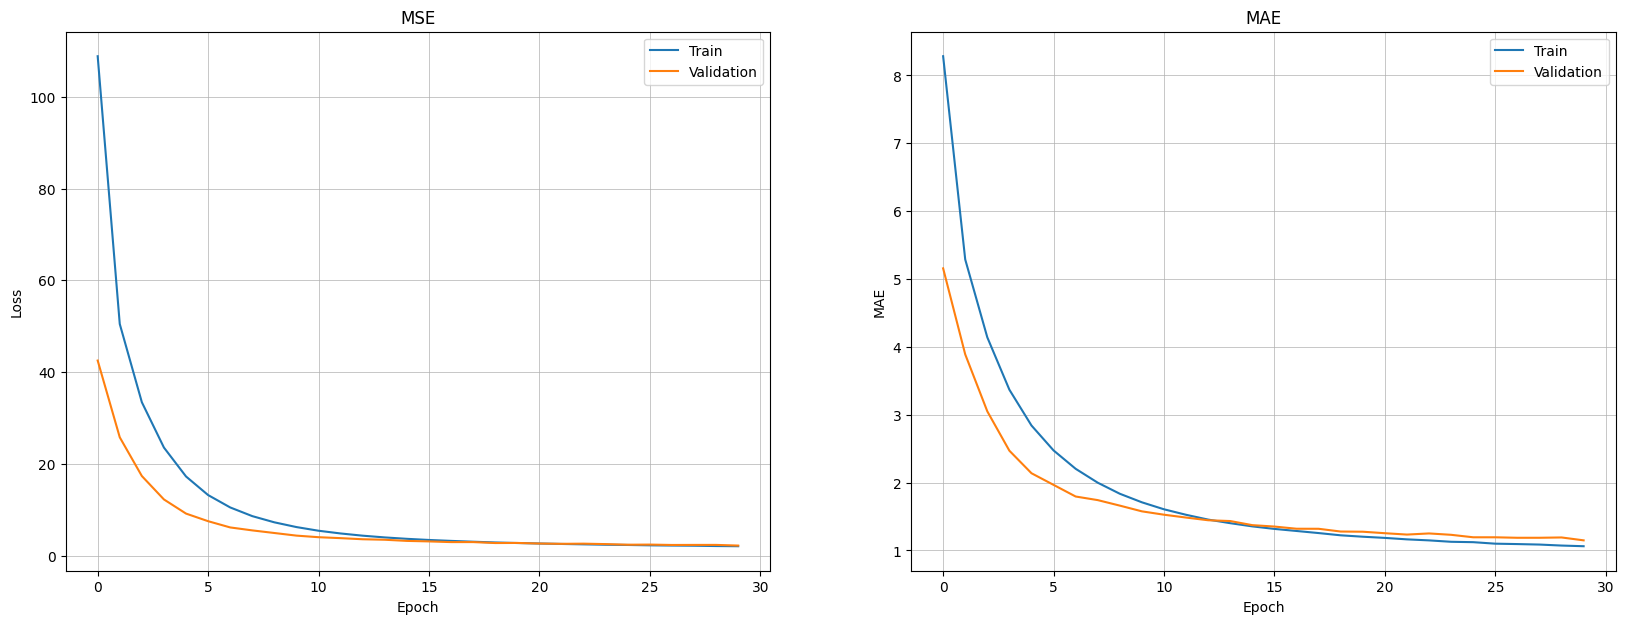

In [38]:
from keras.callbacks import EarlyStopping

def fit_model(model):
    """
    Verilen modeli eğitir ve eğitim geçmişini (history) döndürür.
    """
    # Erken durdurma kriteri ekleyelim ki boşuna beklemesin
    es = EarlyStopping(patience=3, restore_best_weights=True)
    
    # Modeli eğit
    print("Model eğitimi başlıyor...")
    history = model.fit(
        X_train, y_train,
        validation_split=0.2, # Verinin %20'sini doğrulama için kullan
        epochs=30,            # Erken durdurma olduğu için yüksek tutulabilir
        batch_size=32,
        callbacks=[es],
        verbose=1
    )
    
    return model, history

# 1. Modeli başlat
model = init_model(X_train, y_train)

# 2. Modeli eğit
model, history = fit_model(model)

# 3. Test setinde değerlendir
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Seti MAE (Ortalama Mutlak Hata): {test_mae:.3f} derece")

# Eğitim grafiklerini çizdir
plot_history(history)

## (2.2) 💻 LSTM'imizle karşılaştıracağımız Temel Model!

👉 Zaman Serilerinde, "sezgisel" bir temel model, tahmin etmek istediğiniz gelecekteki değer(ler) için **son görülen değeri** tahmin etmektir, aşağıda gösterildiği gibi!

<img src = "https://github.com/lewagon/data-images/blob/master/DL/rnn_time_series_no_horizon.png?raw=true" width = 600, height = 300>

💻 ❓ **Soru (Son Görülen Değer Temel Modeli)** ❓

LSTM'e benzer şekilde bir temel model başlatan ve derleyen yeni bir `init_baseline` yöntemi oluşturun.

- Temel model bir [📚 Keras Lambda Katmanı](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Lambda) olmalıdır
- 0 eğitilebilir parametresi olduğundan `fit` bile gerektirmemelidir
- Sonra, bu KATMAN için MAE'yi hesaplayın ve LSTM'yi eğittikten sonra test setinde elde ettiğiniz MAE ile karşılaştırın
 
<details>
    <summary markdown='span'>💡 <i>İpuçu</i></summary>

- `X_train[:,:,1]`'in sıcaklık zaman seriniz olduğunu unutmayın (`fold`'inizdeki ikinci sütun)
</details>


In [42]:
from keras.layers import Lambda
from keras.models import Sequential

def init_baseline():
    model = Sequential()
    # 0. indeks (basınç) yerine 1. indeks (sıcaklık) kullanıyoruz:
    model.add(Lambda(lambda x: x[:, -1, 1])) 
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


In [43]:
baseline_model = init_baseline()
baseline_score = baseline_model.evaluate(X_test, y_test)
print(f"- The Baseline MAE on the test set is equal to {round(baseline_score[1],2)} Celsius degrees")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.1404 - mae: 4.3324   
- The Baseline MAE on the test set is equal to 4.33 Celsius degrees


In [45]:
# LSTM modelimizin test sonuçlarını 'res' değişkenine atıyoruz
res = model.evaluate(X_test, y_test, verbose=0)

print(f"- The LSTM MAE on the test set is equal to {round(res[1],2)} Celsius degrees")
print(f"🔥 Improvement of the LSTM model over the baseline (on this fold for the test set) = : {round((1 - (res[1]/baseline_score[1]))*100,2)} % 🔥")

- The LSTM MAE on the test set is equal to 1.26 Celsius degrees
🔥 Improvement of the LSTM model over the baseline (on this fold for the test set) = : 71.0 % 🔥


## (2.3) 💻 Çapraz Doğrulama

**"Büyük resmi"** hatırlıyor musunuz?

<br>

<details>
    <summary markdown='span'><i>Büyük resim</i></summary>


<b><u>Adım 1: Zaman Serisinde Çapraz Doğrulama [KATMANLAR] </u></b>

* Bu tekil Zaman Serisinden başlayarak, <font color="#c91ac9">**KATMANLAR**</font> oluşturacağız...
* ... ve sinir ağının sağlamlığı hakkında sonuç çıkarmak için LSTM'i bu farklı <font color="#c91ac9">**KATMANLARDA**</font> eğiteceğiz/değerlendireceğiz
* Zaman Serisi tahminlemede ***yüzlerce*** <font color="#c91ac9">**KATMAN**</font> oluşturmak çok yaygındır, tüm dış koşul tiplerini kapsamak için: örn.
    - çöküş piyasa dönemleri 📉
    - boqa piyasaları 📈
    - düz piyasalar 😴, vb...

<b><u>Adım 2: Her katman içinde Holdout yöntemi [EĞİTİM-TEST AYIRIMI]</u></b>

* Her <font color="#c91ac9">**KATMAN**</font> için, EĞİTİM-TEST AYIRIMI yapacağız:
    * modeli <font color=blue>**eğitim**</font> setinde <font color=blue>**eğitmek**</font>
    * ve <font color="#ff8005">**test**</font> setinde <font color="#ff8005">**değerlendirmek**</font>
    * Eğitim setini her zaman test setinden **kronolojik olarak** önce ayırın!

👇 İlk iki adım, 4 KATMAN içeren aşağıdaki görüntüde özetlenebilir:

<img src="https://bit.ly/3yLoa92" alt="Time Series Cross Validation" width="500" height="500">


<b><u>Adım 3: Hem eğitim setinde hem de test setinde DİZİLER örnekleme</u></b>

Her <font color=blue>**eğitim**</font> setinde ve her <font color="#ff8005">**test**</font> setinde, aşağıda gösterildiği gibi <font color=magenta>**rastgele diziler**</font> oluşturacağız 👇:

<img src="https://bit.ly/3Ri8Vfd" alt="Sequences in each fold" width="500" height="500"> 


</details>

❗️ ***Uyarılar*** ❗️

* <u><i>adım 2</i></u>'yi (<font color="blue">eğitim</font>/<font color="orange">test</font> ayrımı) ve <u><i>adım 3</i></u>'u (get_X_y) yalnızca **<font color="#c91ac9">tek bir KATMAN için</font>** yaptığımızı unutmayın.
* ***Bir modelin sağlamlığını sağlamak istiyorsak, modeli <font color="#c91ac9">TÜM katmanlarda</font> çapraz doğrulamamız gerekir!***


In [46]:
# Bu notebook'taki global değişkenlerin hatırlatması

print(f'N_FEATURES = {N_FEATURES}')
print(f'N_TARGETS = {N_TARGETS}')
print('')
print(f'FOLD_LENGTH = {FOLD_LENGTH}')
print(f'FOLD_STRIDE = {FOLD_STRIDE}')
print(f'TRAIN_TEST_RATIO = {TRAIN_TEST_RATIO}')
print('')
print(f'N_TRAIN = {N_TRAIN}')
print(f'N_TEST = {N_TEST}')
print(f'INPUT_LENGTH = {INPUT_LENGTH}')
print(f'OUTPUT_LENGTH = {OUTPUT_LENGTH}')


N_FEATURES = 19
N_TARGETS = 1

FOLD_LENGTH = 8760
FOLD_STRIDE = 728
TRAIN_TEST_RATIO = 0.66

N_TRAIN = 6666
N_TEST = 3333
INPUT_LENGTH = 112
OUTPUT_LENGTH = 1


In [47]:
# Kaç katmanımız var hatırlıyor musunuz?
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

print(f"UYARI, {len(folds)} KATMANımız var, bu yüzden RNN'ın çapraz doğrulamasını Colab'da çalıştırmak isteyebilirsiniz.")


UYARI, 21 KATMANımız var, bu yüzden RNN'ın çapraz doğrulamasını Colab'da çalıştırmak isteyebilirsiniz.


💻 **❓ Temel modelinizi ve modelinizi bir for-döngüsünde çapraz doğrulayın!❓**

Önceden tanımladığınız yöntemleri yeniden kullanarak:
- `get_folds`
- `train_test_split`
- `get_X_y`
- `init_model`
- `init_baseline`

In [48]:
from keras.callbacks import EarlyStopping

def cross_validate_baseline_and_lstm():
    '''
    Bu fonksiyon şunları çapraz doğrular:
    - "son görülen değer" temel modeli
    - RNN modeli
    '''

    list_of_mae_baseline_model = []
    list_of_mae_recurrent_model = []

    # 0 - Creating folds
    # =========================================
    folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

    for fold_id, fold in enumerate(folds):

        # 1 - Train/Test split the current fold
        # =========================================
        (fold_train, fold_test) = train_test_split(fold, TRAIN_TEST_RATIO, INPUT_LENGTH)

        X_train, y_train = get_X_y(fold_train, N_TRAIN, INPUT_LENGTH, OUTPUT_LENGTH)
        X_test, y_test = get_X_y(fold_test, N_TEST, INPUT_LENGTH, OUTPUT_LENGTH)

        # 2 - Modelling
        # =========================================

        ##### Baseline Model
        baseline_model = init_baseline()
        mae_baseline = baseline_model.evaluate(X_test, y_test, verbose=0)[1]
        list_of_mae_baseline_model.append(mae_baseline)
        print("-"*50)
        print(f"MAE baseline fold n°{fold_id} = {round(mae_baseline, 2)}")

        ##### LSTM Model
        model = init_model(X_train, y_train)
        es = EarlyStopping(monitor = "val_mae",
                           mode = "min",
                           patience = 2,
                           restore_best_weights = True)
        history = model.fit(X_train, y_train,
                            validation_split = 0.3,
                            shuffle = False,
                            batch_size = 32,
                            epochs = 50,
                            callbacks = [es],
                            verbose = 0)
        res = model.evaluate(X_test, y_test, verbose=0)
        mae_lstm = res[1]
        list_of_mae_recurrent_model.append(mae_lstm)
        print(f"MAE LSTM fold n°{fold_id} = {round(mae_lstm, 2)}")

        ##### Comparison LSTM vs Baseline for the current fold
        print(f"🏋🏽‍♂️ improvement over baseline: {round((1 - (mae_lstm/mae_baseline))*100,2)} % \n")

    return list_of_mae_baseline_model, list_of_mae_recurrent_model


In [49]:
%%time
# WARNING : it takes 15 minutes to run this cell (MacBook Air M1)
mae_baselines, mae_lstms = cross_validate_baseline_and_lstm()


--------------------------------------------------
MAE baseline fold n°0 = 9.26
MAE LSTM fold n°0 = 1.22
🏋🏽‍♂️ improvement over baseline: 86.79 % 

--------------------------------------------------
MAE baseline fold n°1 = 8.85
MAE LSTM fold n°1 = 1.23
🏋🏽‍♂️ improvement over baseline: 86.1 % 

--------------------------------------------------
MAE baseline fold n°2 = 9.4
MAE LSTM fold n°2 = 1.27
🏋🏽‍♂️ improvement over baseline: 86.52 % 

--------------------------------------------------
MAE baseline fold n°3 = 9.59
MAE LSTM fold n°3 = 1.26
🏋🏽‍♂️ improvement over baseline: 86.84 % 

--------------------------------------------------
MAE baseline fold n°4 = 9.47
MAE LSTM fold n°4 = 1.18
🏋🏽‍♂️ improvement over baseline: 87.51 % 

--------------------------------------------------
MAE baseline fold n°5 = 9.8
MAE LSTM fold n°5 = 1.21
🏋🏽‍♂️ improvement over baseline: 87.66 % 

--------------------------------------------------
MAE baseline fold n°6 = 9.84
MAE LSTM fold n°6 = 1.19
🏋🏽‍♂️ impr

In [50]:
print(f"temel modele göre ortalama yüzdelik gelişim = {round(np.mean(1 - (np.array(mae_lstms)/np.array(mae_baselines))),2)*100}%")


temel modele göre ortalama yüzdelik gelişim = 87.0%


## Teşekkürler

* Bu meydan okuma gerçekten `Google>Tensorflow>Keras`'tan `Zaman Serisi Tahmini` eğitiminden ilham aldı
* Teknik fonksiyonlar Bruno Lajoie'nin [Zaman Serileri hakkındaki data-template paketi](https://github.com/lewagon/data-templates/tree/main/project-boilerplates)nden ilham aldı

# (Bonus) Orijinal veri seti 

🥋 Özellik mühendisliği becerilerinizi pratik yapmak istiyorsanız, daha sonra bu meydan okumaya geri gelmekte, orijinal veri setini indirmekte ve üzerinde çalışmakta özgürsünüz.

In [53]:
import os
import pandas as pd
import requests
import zipfile
import io

# 1. URL ve Dosya Yolu
url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'
zip_name = 'jena_climate_2009_2016.csv.zip'

print("Veri indiriliyor (SSL güvenliği devre dışı bırakıldı)...")

# 2. Requests ile SSL doğrulamasını (verify=False) kapatarak indiriyoruz
response = requests.get(url, verify=False)

# 3. İnen zip dosyasını hafızada açıyoruz
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # İçindeki CSV dosyasının adını bulalım
    csv_name = z.namelist()[0]
    # CSV'yi okuyup 'raw' değişkenine atayalım
    raw = pd.read_csv(z.open(csv_name))

print(f"Başarıyla indirildi! Veri boyutu: {raw.shape}")
display(raw.head())

Veri indiriliyor (SSL güvenliği devre dışı bırakıldı)...


/Users/macos/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Başarıyla indirildi! Veri boyutu: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [54]:
# Inspecting each feature to detect their type and null values
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


In [55]:
# Slice [start:stop:step],
# starting from index 5, take every 6th record
# to get only hourly records

# 5. indeksten başla (00:00:00 yerine 01:00:00'e denk gelmesi için), sonuna kadar 6'şar atla
raw = raw[5::6]

# Kontrol edelim: Satır sayısı yaklaşık 6 kat azalmalı (~70k olmalı)
print(f"Yeni boyut: {raw.shape}")
raw.head()

Yeni boyut: (70091, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


In [56]:
# Convert the "Date Time" column to a datetime format

# 'Date Time' sütununu pandas datetime objesine çeviriyoruz
raw['Date Time'] = pd.to_datetime(raw['Date Time'], format='%d.%m.%Y %H:%M:%S')

# Tipinin 'datetime64[ns]' olduğunu doğrulamak için info'ya tekrar bakalım
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70091 entries, 5 to 420545
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date Time        70091 non-null  datetime64[ns]
 1   p (mbar)         70091 non-null  float64       
 2   T (degC)         70091 non-null  float64       
 3   Tpot (K)         70091 non-null  float64       
 4   Tdew (degC)      70091 non-null  float64       
 5   rh (%)           70091 non-null  float64       
 6   VPmax (mbar)     70091 non-null  float64       
 7   VPact (mbar)     70091 non-null  float64       
 8   VPdef (mbar)     70091 non-null  float64       
 9   sh (g/kg)        70091 non-null  float64       
 10  H2OC (mmol/mol)  70091 non-null  float64       
 11  rho (g/m**3)     70091 non-null  float64       
 12  wv (m/s)         70091 non-null  float64       
 13  max. wv (m/s)    70091 non-null  float64       
 14  wd (deg)         70091 non-null  floa

In [57]:
# Describe the dataset

# Sayısal sütunların istatistiksel özetini görelim
raw.describe()


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,70091,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000,70091.000000
mean,2012-12-30 06:26:49.413476608,989.212842,9.450482,283.493086,4.956471,76.009788,13.576576,9.533968,4.042536,6.022560,9.640437,1216.061232,1.702567,2.963041,174.789095
min,2009-01-01 01:00:00,913.600000,-22.760000,250.850000,-24.800000,13.880000,0.970000,0.810000,0.000000,0.510000,0.810000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,2010-12-31 03:50:00,984.200000,3.350000,277.440000,0.240000,65.210000,7.770000,6.220000,0.870000,3.920000,6.290000,1187.470000,0.990000,1.760000,125.300000
50%,2012-12-30 06:20:00,989.570000,9.410000,283.460000,5.210000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.800000,1.760000,2.980000,198.100000
75%,2014-12-29 18:30:00,994.720000,15.480000,289.530000,10.080000,89.400000,17.610000,12.360000,5.300000,7.800000,12.490000,1242.765000,2.860000,4.740000,234.000000
max,2016-12-31 23:10:00,1015.290000,37.280000,311.210000,23.060000,100.000000,63.770000,28.250000,46.010000,18.070000,28.740000,1393.540000,14.010000,23.500000,360.000000
std,NaN,8.358886,8.423384,8.504424,6.730081,16.474920,7.739883,4.183658,4.898549,2.655812,4.234862,39.974263,65.447512,75.597657,86.619431


In [58]:
## Fixing the wv, look at the absurd values and replace them with zero

# 'wv (m/s)' sütunundaki -9999.0 değerlerini yakalayıp 0.0 yapıyoruz
bad_wv = raw['wv (m/s)'] == -9999.0
raw.loc[bad_wv, 'wv (m/s)'] = 0.0

# Kontrol için min değerine bakalım (Artık negatif olmamalı)
print(f"Yeni minimum wv: {raw['wv (m/s)'].min()}")

## Fixing the max wv

# 'max. wv (m/s)' sütunundaki -9999.0 değerlerini 0.0 ile değiştiriyoruz
bad_max_wv = raw['max. wv (m/s)'] == -9999.0
raw.loc[bad_max_wv, 'max. wv (m/s)'] = 0.0

# Kontrol
print(f"Yeni minimum max wv: {raw['max. wv (m/s)'].min()}")


Yeni minimum wv: 0.0
Yeni minimum max wv: 0.0


--------------------------------------------------
Working with angles...


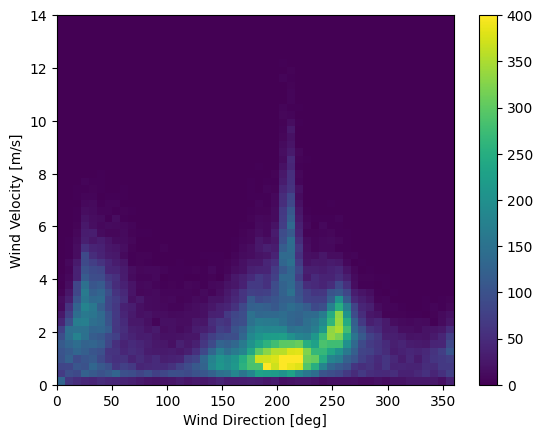

--------------------------------------------------
Working with wind vectors


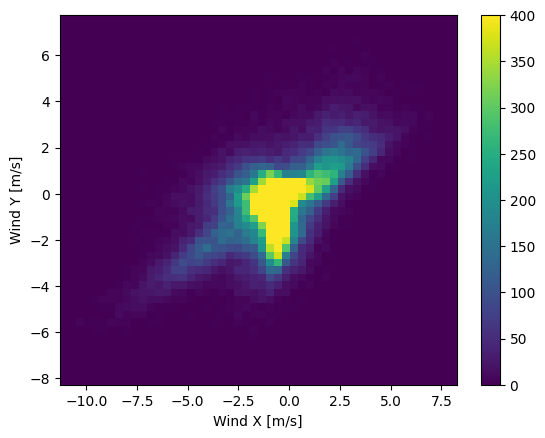

In [59]:
# Wind : Wd degrees from 0 to 360 egrees
# Angles do not make good models inputs because 0 and 360 should be "close"

import numpy as np
import matplotlib.pyplot as plt


df = raw

print('-'*50)
print("Working with angles...")

plt.hist2d(df['wd (deg)'], df['wv (m/s)'],
           bins=(50, 50),
           vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')
plt.show()

# --- ÖZELLİK MÜHENDİSLİĞİ BAŞLANGICI ---

# 1. Dereceleri radyana çeviriyoruz
wd_rad = df['wd (deg)'] * np.pi / 180

# 2. Rüzgarın x ve y bileşenlerini hesaplayıp yeni sütunlara ekliyoruz
df['Wx'] = df['wv (m/s)'] * np.cos(wd_rad)
df['Wy'] = df['wv (m/s)'] * np.sin(wd_rad)

# 3. Maksimum rüzgar hızı için x ve y bileşenlerini hesaplıyoruz
df['max Wx'] = df['max. wv (m/s)'] * np.cos(wd_rad)
df['max Wy'] = df['max. wv (m/s)'] * np.sin(wd_rad)

# --- ÖZELLİK MÜHENDİSLİĞİ BİTİŞİ ---

print('-'*50)
print("Working with wind vectors")

plt.hist2d(df['Wx'], df['Wy'],
           bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')
plt.show()
# $CHALLENGIFY_END


In [60]:
# Similarly to the wind direction, the time in seconds is not a useful model input
# The weather dataset has clear daily and yearly periodicities
# Using sine and cosine functions, we can compute:
# - the time of the day
# - the time of the year

import numpy as np

# 1. Tarihleri saniye (timestamp) cinsinden alalım
timestamp_s = df['Date Time'].map(pd.Timestamp.timestamp)

# 2. Günlük ve yıllık saniye sabitleri
day = 24*60*60
year = (365.2425)*day

# 3. Günün saati için sin/cos hesaplama
df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))

# 4. Yılın günü için sin/cos hesaplama
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

# Kontrol etmek için ilk birkaç satırı görelim
df[['Day sin', 'Day cos', 'Year sin', 'Year cos']].head()


,Day sin,Day cos,Year sin,Year cos
5,0.258819,0.965926,0.010049,0.999950
11,0.500000,0.866025,0.010766,0.999942
17,0.707107,0.707107,0.011483,0.999934
23,0.866025,0.500000,0.012199,0.999926
29,0.965926,0.258819,0.012916,0.999917


In [61]:
# Select every 3 hours

# Her 3. satırı seçiyoruz (3 saatlik adımlar için)
df = df[::3]

# Verinin boyutuna bakalım, iyice azaldığını göreceksin
print(f"3 saatlik veriye düşürüldü. Yeni boyut: {df.shape}")
df.head()


3 saatlik veriye düşürüldü. Yeni boyut: (23364, 23)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos
5,2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7,-0.204862,-0.046168,-0.614587,-0.138503,0.258819,0.965926,0.010049,0.999950
23,2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0,-0.050000,-0.086603,-0.190000,-0.329090,0.866025,0.500000,0.012199,0.999926
41,2009-01-01 07:00:00,998.33,-9.17,264.12,-10.10,92.9,3.04,2.83,0.22,1.76,2.83,1315.98,2.08,2.88,348.8,2.040387,-0.404007,2.825151,-0.559395,0.965926,-0.258819,0.014349,0.999897
59,2009-01-01 10:00:00,1000.27,-7.04,266.10,-8.17,91.6,3.60,3.30,0.30,2.05,3.29,1307.76,1.45,3.00,292.6,0.557228,-1.338655,1.152886,-2.769631,0.500000,-0.866025,0.016500,0.999864
77,2009-01-01 13:00:00,1000.03,-5.89,267.27,-7.46,88.6,3.93,3.48,0.45,2.17,3.48,1301.73,0.57,1.25,187.3,-0.565380,-0.072427,-1.239868,-0.158831,-0.258819,-0.965926,0.018650,0.999826
